# Required Libraries

In [1]:
# All libraries here

# Basic libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# Others
from xgboost import XGBRegressor

# Original Demographic Specific Dataset

In [17]:
# Loading the demographic specific dataset
original_df = pd.read_csv(os.path.join('data', 'demographic_specific_dataset.csv'))

# Data Acquisition

In [18]:
original_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 554400 entries, 0 to 554399
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   datetime                    554400 non-null  str    
 1   athlete                     554400 non-null  int64  
 2   block_id                    554400 non-null  str    
 3   distance                    554400 non-null  float64
 4   duration                    554400 non-null  float64
 5   days_until_marathon         554400 non-null  int64  
 6   marathon_count_until_2019   554400 non-null  int64  
 7   marathon_count_2019         554400 non-null  int64  
 8   avg_activity_pace           554400 non-null  float64
 9   cumulative_duration         554400 non-null  float64
 10  cumulative_distance         554400 non-null  float64
 11  performance_category        554400 non-null  int64  
 12  fastest_pace                554400 non-null  float64
 13  slowest_pace             

In [19]:
original_df.head(10)

,datetime,athlete,block_id,distance,duration,days_until_marathon,marathon_count_until_2019,marathon_count_2019,avg_activity_pace,cumulative_duration,...,min_distance,max_distance,active_streak,rest_streak,duration_last_7_days,distance_last_7_days,weekly_cumulative_duration,weekly_cumulative_distance,avg_race_pace,marathon_race_time
0,2018-12-24,15,15_boston,0.00,0.0,-112,2,1,0.000000,0.0,...,0.00,0.00,0,1,0.0,0.00,0.0,0.00,4.661017,198.0
1,2018-12-25,15,15_boston,0.00,0.0,-111,2,1,0.000000,0.0,...,0.00,0.00,0,2,0.0,0.00,0.0,0.00,4.661017,198.0
2,2018-12-26,15,15_boston,0.00,0.0,-110,2,1,0.000000,0.0,...,0.00,0.00,0,3,0.0,0.00,0.0,0.00,4.661017,198.0
3,2018-12-27,15,15_boston,0.00,0.0,-109,2,1,0.000000,0.0,...,0.00,0.00,0,4,0.0,0.00,0.0,0.00,4.661017,198.0
4,2018-12-28,15,15_boston,0.00,0.0,-108,2,1,0.000000,0.0,...,0.00,0.00,0,5,0.0,0.00,0.0,0.00,4.661017,198.0
5,2018-12-29,15,15_boston,0.00,0.0,-107,2,1,0.000000,0.0,...,0.00,0.00,0,6,0.0,0.00,0.0,0.00,4.661017,198.0
6,2018-12-30,15,15_boston,0.00,0.0,-106,2,1,0.000000,0.0,...,0.00,0.00,0,7,0.0,0.00,0.0,0.00,4.661017,198.0
7,2018-12-31,15,15_boston,0.00,0.0,-105,2,1,0.000000,0.0,...,0.00,0.00,0,8,0.0,0.00,0.0,0.00,4.661017,198.0
8,2019-01-01,15,15_boston,19.49,95.0,-104,2,1,4.874295,95.0,...,19.49,19.49,1,0,95.0,19.49,95.0,19.49,4.661017,198.0
9,2019-01-02,15,15_boston,2.54,24.3,-103,2,1,9.566929,119.3,...,2.54,19.49,2,0,119.3,22.03,119.3,22.03,4.661017,198.0


In [20]:
original_df.tail(10)

,datetime,athlete,block_id,distance,duration,days_until_marathon,marathon_count_until_2019,marathon_count_2019,avg_activity_pace,cumulative_duration,...,min_distance,max_distance,active_streak,rest_streak,duration_last_7_days,distance_last_7_days,weekly_cumulative_duration,weekly_cumulative_distance,avg_race_pace,marathon_race_time
554390,2019-10-24,37520,37520_new_york,0.00,0.0,-10,1,1,0.000000,1093.75,...,1.76,21.09,0,1,174.10,42.72,92.1,21.63,4.668074,199.0
554391,2019-10-25,37520,37520_new_york,0.00,0.0,-9,1,1,0.000000,1093.75,...,1.76,21.09,0,2,174.10,42.72,92.1,21.63,4.668074,199.0
554392,2019-10-26,37520,37520_new_york,0.00,0.0,-8,1,1,0.000000,1093.75,...,1.76,21.09,0,3,92.10,21.63,92.1,21.63,4.668074,199.0
554393,2019-10-27,37520,37520_new_york,0.00,0.0,-7,1,1,0.000000,1093.75,...,1.76,21.09,0,4,92.10,21.63,0.0,0.00,4.668074,199.0
554394,2019-10-28,37520,37520_new_york,0.00,0.0,-6,1,1,0.000000,1093.75,...,1.76,21.09,0,5,42.35,9.72,0.0,0.00,4.668074,199.0
554395,2019-10-29,37520,37520_new_york,0.00,0.0,-5,1,1,0.000000,1093.75,...,1.76,21.09,0,6,42.35,9.72,0.0,0.00,4.668074,199.0
554396,2019-10-30,37520,37520_new_york,15.02,68.0,-4,1,1,4.527297,1161.75,...,1.76,21.09,1,0,68.00,15.02,68.0,15.02,4.668074,199.0
554397,2019-10-31,37520,37520_new_york,0.00,0.0,-3,1,1,0.000000,1161.75,...,1.76,21.09,0,1,68.00,15.02,68.0,15.02,4.668074,199.0
554398,2019-11-01,37520,37520_new_york,0.00,0.0,-2,1,1,0.000000,1161.75,...,1.76,21.09,0,2,68.00,15.02,68.0,15.02,4.668074,199.0
554399,2019-11-02,37520,37520_new_york,0.00,0.0,-1,1,1,0.000000,1161.75,...,1.76,21.09,0,3,68.00,15.02,68.0,15.02,4.668074,199.0


In [21]:
original_df.isnull().sum()

datetime                      0
athlete                       0
block_id                      0
distance                      0
duration                      0
days_until_marathon           0
marathon_count_until_2019     0
marathon_count_2019           0
avg_activity_pace             0
cumulative_duration           0
cumulative_distance           0
performance_category          0
fastest_pace                  0
slowest_pace                  0
weekly_fastest_pace           0
weekly_slowest_pace           0
min_duration                  0
max_duration                  0
min_distance                  0
max_distance                  0
active_streak                 0
rest_streak                   0
duration_last_7_days          0
distance_last_7_days          0
weekly_cumulative_duration    0
weekly_cumulative_distance    0
avg_race_pace                 0
marathon_race_time            0
dtype: int64

In [22]:
original_df.isna().sum()

datetime                      0
athlete                       0
block_id                      0
distance                      0
duration                      0
days_until_marathon           0
marathon_count_until_2019     0
marathon_count_2019           0
avg_activity_pace             0
cumulative_duration           0
cumulative_distance           0
performance_category          0
fastest_pace                  0
slowest_pace                  0
weekly_fastest_pace           0
weekly_slowest_pace           0
min_duration                  0
max_duration                  0
min_distance                  0
max_distance                  0
active_streak                 0
rest_streak                   0
duration_last_7_days          0
distance_last_7_days          0
weekly_cumulative_duration    0
weekly_cumulative_distance    0
avg_race_pace                 0
marathon_race_time            0
dtype: int64

# Data Cleaning

Below is a list of unwanted features that will be dropped from the dataset. These were only relevant for sequential models as they show progression over time:
- cumulative_duration      
- cumulative_distance      
- weekly_fastest_pace        
- weekly_slowest_pace 
- duration_last_7_days      
- distance_last_7_days      
- weekly_cumulative_duration 
- weekly_cumulative_distance

In [23]:
# Checking for any outliers in the dataset
cleaned_original_df = original_df.copy()

perf_cat_1_athletes = (cleaned_original_df['performance_category'] == 1).any()
print(f"Performance Category 1 athletes (outliers): {perf_cat_1_athletes}")

Performance Category 1 athletes (outliers): False


In [25]:
# Removing any unwanted columns from the dataset
cleaned_original_df = original_df.copy()

features_to_drop = ['cumulative_duration', 'cumulative_distance', 'weekly_fastest_pace', 'weekly_slowest_pace', 
                    'duration_last_7_days', 'distance_last_7_days', 'weekly_cumulative_duration', 'weekly_cumulative_distance']

# Dropping the unwanted features
cleaned_original_df.drop(features_to_drop, axis=1, inplace=True)

# Saving the dataset
cleaned_original_df.to_csv(os.path.join('data', 'cleaned_demographic_specific_dataset.csv'), index=False)

In [26]:
# Checking the list of features
cleaned_original_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 554400 entries, 0 to 554399
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   datetime                   554400 non-null  str    
 1   athlete                    554400 non-null  int64  
 2   block_id                   554400 non-null  str    
 3   distance                   554400 non-null  float64
 4   duration                   554400 non-null  float64
 5   days_until_marathon        554400 non-null  int64  
 6   marathon_count_until_2019  554400 non-null  int64  
 7   marathon_count_2019        554400 non-null  int64  
 8   avg_activity_pace          554400 non-null  float64
 9   performance_category       554400 non-null  int64  
 10  fastest_pace               554400 non-null  float64
 11  slowest_pace               554400 non-null  float64
 12  min_duration               554400 non-null  float64
 13  max_duration               554400 non-nu

# Data Exploration & Transformation

This phase was held within another similar project on the demographic specific dataset used within this research. Therefore, no code will be preset here. Also it is not the purpose of this study to explore the dataset.

# Feature Engineering & Aggregation

Below is a list of features that will either be kept for filtering or converted to an aggregated feature. The same process will be used to develop the timeframe reduced datasets (from 16 weeks to 8 weeks):
- datetime -> kept for possible filtering and keeping chronological order (the last day before the marathon event (days_until_marathon = -1) will be kept)
- athlete, block_id -> kept for possible filtering, grouping, and for keeping chronological order                 
- distance -> converted to: total_distance (showing the total amount of kilometers covered during the training period)                 
- duration -> converted to: total_duration (showing the total amount of minutes spent training during the training period)                
- days_until_marathon -> kept for dataset volume reduction (this is used as an indicator of how many days should be used for each dataset)       
- marathon_count_until_2019 -> kept the same, not altered (shows experience)
- marathon_count_2019 -> kept the same, not altered (shows experience)
- performance_category -> kept for possible outlier removal/exclusion (the first occurrence will be extracted)      
- avg_activity_pace -> converted to avg_tb_pace (this show the average pace in min/km during the training block (tb))         
- fastest_pace -> the smallest value is kept in min/km           
- slowest_pace -> the largest value is kept in min/km            
- min_duration -> the smallest value is kept             
- max_duration -> the largest value is kept             
- min_distance -> the smallest value is kept             
- max_distance -> the largest value is kept             
- active_streak -> converted to: total_active_days (showing the amount of days the athlete trained)             
- rest_streak -> converted to: total_rest_days (showing the amount of days the athlete rested for)              
- avg_race_pace -> kept the same, not altered, it is a target value            
- marathon_race_time -> kept the same, not altered, it is a target value

Regarding the days_until_marathon feature, the following thresholds will be used to create the required timeframe reduced datasets for model training/test and evaluation:
- 16 weeks = -112 days
- 14 weeks = -98 days
- 12 weeks = -84 days
- 10 weeks = -70 days
- 8 weeks = -56 days
- 6 weeks = -42 days

Outlier removal was also held, and these outliers were identified by the performance category being 1 (the slowest)

In [62]:
# The original cleaned dataset will be used each time to create timeframe reduced datasets
cleaned_df = pd.read_csv(os.path.join('data', 'cleaned_demographic_specific_dataset.csv'))

In [ ]:
# Creating the thresholds that represent different weeks of training
tb_thresholds = { 
    "16_week_tb.csv": -112, "14_week_tb.csv": -98, "12_week_tb.csv": -84, 
    "10_week_tb.csv": -70, "8_week_tb.csv": -56, "6_week_tb.csv": -42
}

# Loop through both the filenames (keys) and thresholds (values)
for filename, threshold in tb_thresholds.items():
    # Getting a copy of the cleaned dataset
    df = cleaned_df.copy()
    
    # Filter the dataset for the specific timeframe
    # Note: Since the days are negative and counting up to 0 (race day), 
    filtered_df = df[df['days_until_marathon'] >= threshold]
    
    # Save the reduced dataset to a CSV file
    # index=False prevents pandas from writing the row indices into the file
    filtered_df.to_csv(os.path.join('data', 'sequential_data', filename), index=False)
    
    print(f"Saved {filename} with threshold >= {threshold}")

Saved 16_week_tb.csv with threshold >= -112
Saved 14_week_tb.csv with threshold >= -98
Saved 12_week_tb.csv with threshold >= -84
Saved 10_week_tb.csv with threshold >= -70
Saved 8_week_tb.csv with threshold >= -56
Saved 6_week_tb.csv with threshold >= -42
Saved 4_week_tb.csv with threshold >= -28


After filtering the dataset to the specified thresholds, the data will be aggregated whilst feature engineering is performed.

In [ ]:
# Creating an array holding the file names
sequential_data = [ 
    "16_week_tb.csv", "14_week_tb.csv", "12_week_tb.csv", 
    "10_week_tb.csv", "8_week_tb.csv", "6_week_tb.csv"
]

for file in sequential_data:
    # Loading the csv data file
    df = pd.read_csv(os.path.join('data', 'sequential_data', file))

    # Converting the datetime string into an object
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Sorting the data chronologically
    df = df.sort_values(by=['block_id', 'datetime'])
    
    # Defining the aggregation logic for each feature
    # For active/rest streaks, assuming a > 0 value means the day was active/rest,
    # we use a lambda function to count how many days meet that condition.
    agg_dict = {
        'datetime': 'last',                         # Grabs the date closest to the marathon
        'athlete': 'first',                         # Static value, keep first
        'distance': 'sum',                          # Sums total distance
        'duration': 'sum',                          # Sums total duration
        'days_until_marathon': 'min',               # Grabs the starting day (e.g., -98)
        'marathon_count_until_2019': 'first',       # Static value, keep first
        'marathon_count_2019': 'first',             # Static value, keep first
        'avg_activity_pace': 'mean',                # Averages the daily paces
        'performance_category': 'first',            # Static value, keep first
        'fastest_pace': 'min',                      # Smallest min/km is the fastest
        'slowest_pace': 'max',                      # Largest min/km is the slowest
        'min_duration': 'min',                      # Smallest duration
        'max_duration': 'max',                      # Largest duration
        'min_distance': 'min',                      # Smallest distance
        'max_distance': 'max',                      # Largest distance
        'active_streak': lambda x: (x > 0).sum(),   # Counts total active days
        'rest_streak': lambda x: (x > 0).sum(),     # Counts total rest days
        'avg_race_pace': 'first',                   # Target value, keep first
        'marathon_race_time': 'first'               # Target value, keep first
    }
    
    # Grouping by block_id, then applying the aggregation rules
    # reset_index() turns the grouped columns back into regular columns
    agg_df = df.groupby(['block_id']).agg(agg_dict).reset_index()

    # New feature
    # Get the index of the feature after which the new feature will be placed
    target_idx = agg_df.columns.get_loc('days_until_marathon')

    # Create and insert the new positive metric from the negative countdown
    agg_df.insert(target_idx + 1, 'tb_length', agg_df['days_until_marathon'].abs())
    
    # Renaming specific columns for clarity
    agg_df.rename(columns={
        'distance': 'total_distance',
        'duration': 'total_duration',
        'avg_activity_pace': 'avg_tb_pace',
        'active_streak': 'total_active_days',
        'rest_streak': 'total_rest_days'
    }, inplace=True)
    
    # Sorting and saving the newly aggregated dataset
    agg_df['datetime'] = pd.to_datetime(agg_df['datetime'])
    agg_df = agg_df.sort_values(by=['datetime', 'athlete', 'block_id'])

    save_name = f"agg_{file}"
    agg_df.to_csv(os.path.join('data', 'aggregated_data', save_name), index=False)
    
    print(f"Successfully aggregated and saved: {save_name}, Sanity Check - Row count: {len(agg_df)}")

Successfully aggregated and saved: agg_16_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_14_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_12_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_10_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_8_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_6_week_tb.csv, Sanity Check - Row count: 4950
Successfully aggregated and saved: agg_4_week_tb.csv, Sanity Check - Row count: 4950


# Data Preprocessing

This stage is integrated within the next phase, where the data files are split using an 80:20 train-test ratio and a random seed before model training. Thus no code will be present in this section.

# Model Creation, Training & Evaluation

All model architectures related to Linear Regression and the Random Forest Regressor were taken directly from the reference solution. The XGBoost model was developed based on certain criteria (i.e. control variables) within the reference solution.

## Baseline Models

First the baseline models and the created dataset will be used from the sample solution to serve as benchmark models. This dataset consists of randomly selected training block lengths, all the genders, the country, age group. No additional features were really and truly developed, only the total distance and duration, overall marathon count, and total training days were engineered.

In [2]:
# Loading the developed aggregated dataset used within the sample solution
ref_sol_agg_df = pd.read_csv(os.path.join('..', '01 - sample solution', 'df_aggregated.csv'))
ref_sol_agg_df.head(5)

,athlete,m_date,m_name_,datetime_min,datetime_max,distance_mean,distance_sum,distance_count,duration_mean,duration_sum,gender,age_group,country,m_time,prev_m_years,overall_m_count,total_days,avg_pace
0,0,2019-10-13,CHICAGO 2019,2019-06-03,2019-10-12,10.490000,555.970,53,64.159119,3400.433333,F,18 - 34,United States,283.0,[2019],1,132,6.116217
1,2,2019-04-28,LONDON 2019,2019-01-05,2019-04-25,11.847617,710.857,60,67.079444,4024.766667,M,35 - 54,United Kingdom,237.0,"[2018, 2019]",2,111,5.661851
2,8,2019-04-28,LONDON 2019,2019-01-01,2019-04-27,11.192130,514.838,46,64.823913,2981.900000,M,35 - 54,United Kingdom,239.0,[2019],1,117,5.791919
3,12,2019-04-28,LONDON 2019,2019-01-01,2019-04-13,16.233603,941.549,58,86.204023,4999.833333,M,35 - 54,United Kingdom,218.0,[2019],1,103,5.310221
4,13,2019-04-28,LONDON 2019,2019-01-05,2019-04-21,14.749694,530.989,36,77.946759,2806.083333,M,35 - 54,United Kingdom,226.0,[2019],1,107,5.284636


### Linear Regression

Benchmark Linear Regression Model ~
MAE: 27.98 minutes
RMSE: 36.76 minutes
R² Score: 0.47


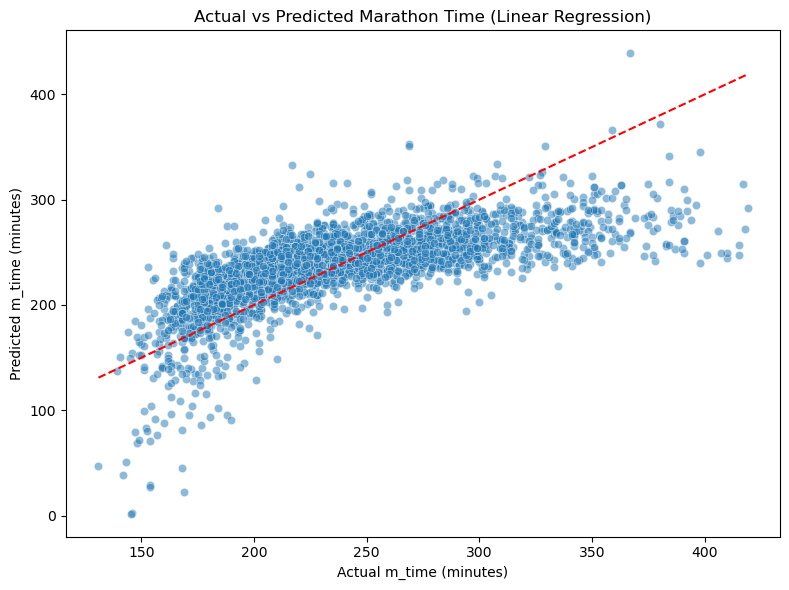

In [ ]:
# --- Features to use ---
features = [
    'distance_sum',
    'duration_sum',
    'overall_m_count',
    'total_days',
    'gender',
    'age_group',
    'country'
]
target = 'm_time'  

# --- Drop rows with missing target ---
ref_sol_agg_df = ref_sol_agg_df.dropna(subset=[target])

# --- Encode categorical features ---
X = pd.get_dummies(ref_sol_agg_df[features])
y = ref_sol_agg_df[target]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train a Random Forest model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Benchmark Linear Regression Model ~")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.2f}")

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual m_time (minutes)')
plt.ylabel('Predicted m_time (minutes)')
plt.title('Actual vs Predicted Marathon Time (Linear Regression)')
plt.tight_layout()
plt.show()

### Random Forest

Benchmark Random Forest Regression Model ~
MAE: 21.84 minutes
RMSE: 30.15 minutes
R² Score: 0.64


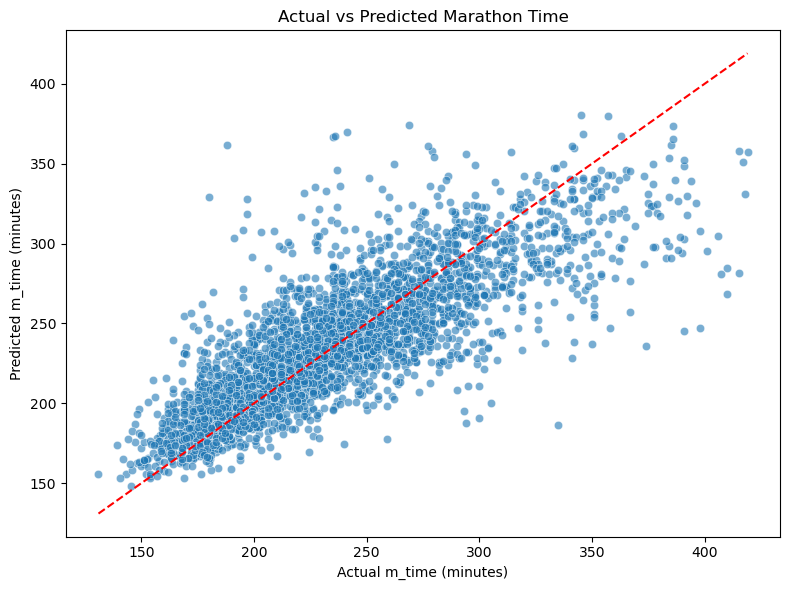

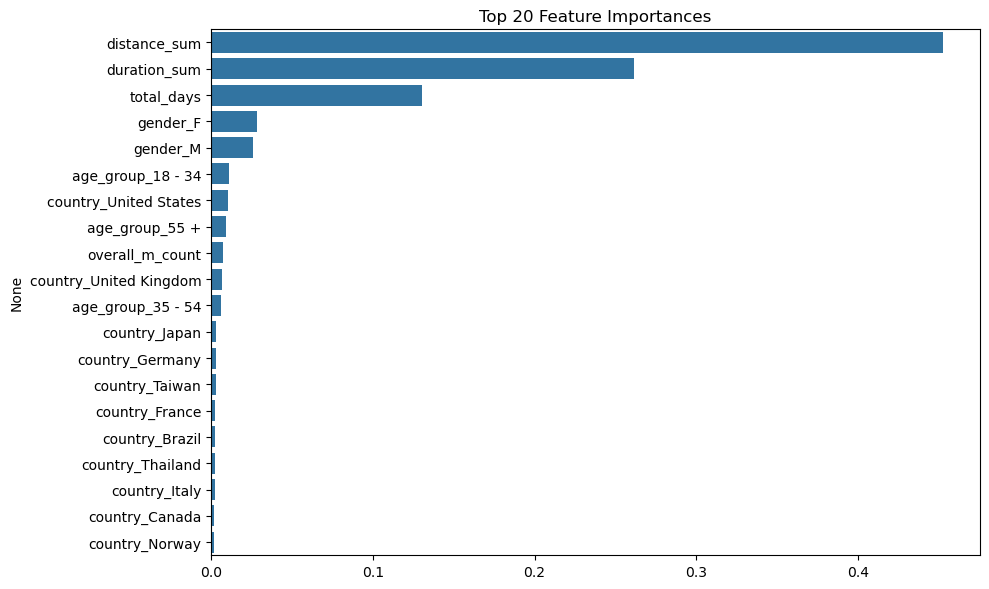

In [6]:
# --- Features to use ---
features = [
    'distance_sum',
    'duration_sum',
    'overall_m_count',
    'total_days',
    'gender',
    'age_group',
    'country'
]
target = 'm_time'


# --- Encode categorical features ---
X = pd.get_dummies(ref_sol_agg_df[features])
y = ref_sol_agg_df[target]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train a Random Forest model ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
r2 = r2_score(y_test, y_pred)

print("Benchmark Random Forest Regression Model ~")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.2f}")

# --- Plot predictions vs actual ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual m_time (minutes)")
plt.ylabel("Predicted m_time (minutes)")
plt.title("Actual vs Predicted Marathon Time")
plt.tight_layout()
plt.show()

# --- Feature importances ---
importances = model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

### XGBoost

Benchmark XGBoost Regression Model ~
MAE: 21.39 minutes
RMSE: 29.68 minutes
R² Score: 0.65


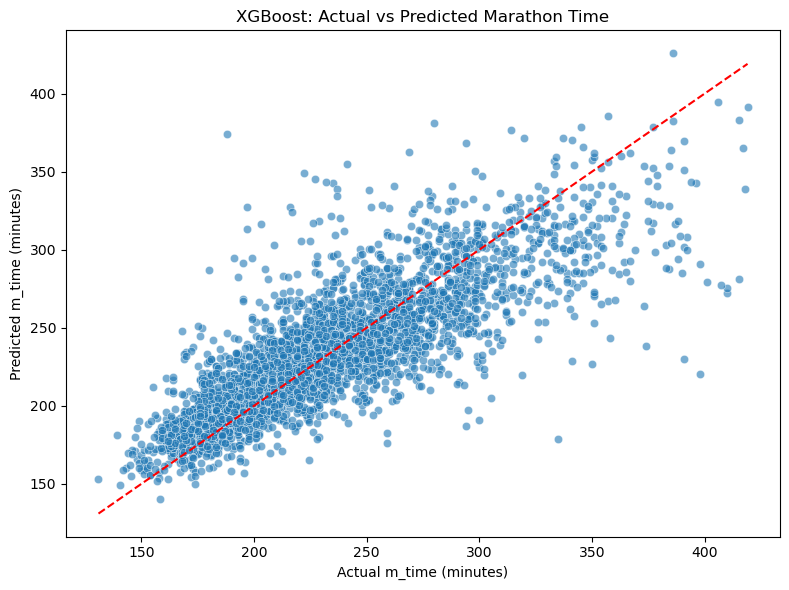

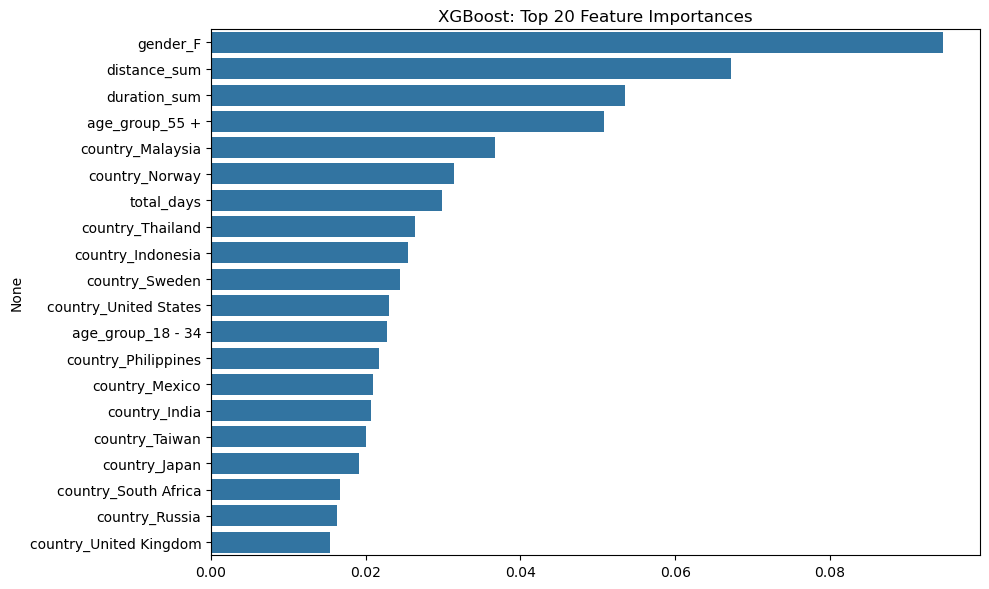

In [7]:
# --- Features to use ---
features = [
    'distance_sum',
    'duration_sum',
    'overall_m_count',
    'total_days',
    'gender',
    'age_group',
    'country'
]
target = 'm_time'

# --- Encode categorical features ---
X = pd.get_dummies(ref_sol_agg_df[features])
y = ref_sol_agg_df[target]

# --- Train-test split (Identical Controls) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train an XGBoost model ---
# n_jobs=-1 tells XGBoost to use all available CPU cores to train faster
model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
r2 = r2_score(y_test, y_pred)

print("Benchmark XGBoost Regression Model ~")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.2f}")

# --- Plot predictions vs actual ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual m_time (minutes)")
plt.ylabel("Predicted m_time (minutes)")
plt.title("XGBoost: Actual vs Predicted Marathon Time")
plt.tight_layout()
plt.show()

# --- Feature importances ---
importances = model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("XGBoost: Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## Timeframe Reduced Models

Below, a series of experiments will be conducted using 16 to 6 weeks of aggregated training data, in two week intervals, filtered to the dominant demographic within the dataset (Males - 35 to 54 years), with additional engineered features. The country feature will not be used as it was deemed irrelevant since it was an estimated guess and might not be accurate. Predictive performance will assess how Random Forest and XGBoost regression models cater for this loss of essential data. The same model architectures will be used for a fair comparison. Each model will be tested 3 times for validity and reproducibility.

### 16 Weeks

In [84]:
# Loading the data
df_16_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_16_week_tb.csv'))
df_16_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,1010.590,4612.233333,-112,112,2,1,2.615772,...,0.0,9.566929,0.0,159.000000,0.0,35.46,63,49,4.661017,198.0
1,61_boston,2019-04-14,61,1491.260,7567.950000,-112,112,3,1,4.670561,...,0.0,5.644853,0.0,159.000000,0.0,31.17,102,10,4.688233,200.0
2,72_boston,2019-04-14,72,1718.049,7600.966667,-112,112,1,1,3.917741,...,0.0,17.181796,0.0,238.483333,0.0,45.01,98,14,3.962264,168.0
3,85_boston,2019-04-14,85,1090.938,4546.566667,-112,112,1,1,2.680981,...,0.0,4.792899,0.0,145.000000,0.0,35.88,72,40,3.799858,161.0
4,89_boston,2019-04-14,89,415.969,1972.583333,-112,112,1,1,1.635081,...,0.0,6.090412,0.0,124.000000,0.0,26.05,38,74,5.060918,216.0


In [85]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_16_weeks[features])
y = df_16_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 16 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

        # # --- Plot predictions vs actual ---
        # plt.figure(figsize=(8, 6))
        # sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
        # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
        # plt.xlabel("Actual m_time (minutes)")
        # plt.ylabel("Predicted m_time (minutes)")
        # plt.title(f"Test {i}: {model_name} Actual vs Predicted Marathon Time")
        # plt.tight_layout()
        # plt.show()

        # # --- Feature importances ---
        # importances = model.feature_importances_
        # feat_names = X.columns

        # feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
        # plt.figure(figsize=(10, 6))
        # sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
        # plt.title(f"Test {i}: {model_name} Top 20 Feature Importances")
        # plt.tight_layout()
        # plt.show()

TEST 1 (Random Seed: 42)
--- 16 Week Random Forest Regression Model ---
MAE: 18.18 minutes
RMSE: 25.03 minutes
R² Score: 0.62

--- 16 Week XGBoost Regression Model ---
MAE: 18.61 minutes
RMSE: 25.74 minutes
R² Score: 0.60

TEST 2 (Random Seed: 52)
--- 16 Week Random Forest Regression Model ---
MAE: 18.79 minutes
RMSE: 25.46 minutes
R² Score: 0.61

--- 16 Week XGBoost Regression Model ---
MAE: 19.67 minutes
RMSE: 26.63 minutes
R² Score: 0.57

TEST 3 (Random Seed: 62)
--- 16 Week Random Forest Regression Model ---
MAE: 17.49 minutes
RMSE: 23.59 minutes
R² Score: 0.66

--- 16 Week XGBoost Regression Model ---
MAE: 18.60 minutes
RMSE: 25.14 minutes
R² Score: 0.61



### 14 Weeks

In [86]:
# Loading the data
df_14_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_14_week_tb.csv'))
df_14_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,942.130,4280.883333,-98,98,2,1,2.701990,...,4.198211,9.566929,24.300000,159.000000,2.54,35.46,58,40,4.661017,198.0
1,61_boston,2019-04-14,61,1397.070,7087.883333,-98,98,3,1,5.023821,...,4.569688,5.644853,33.650000,159.000000,6.57,31.17,96,2,4.688233,200.0
2,72_boston,2019-04-14,72,1619.879,6995.966667,-98,98,1,1,4.080646,...,3.983457,17.181796,38.133333,238.483333,6.36,45.01,92,6,3.962264,168.0
3,85_boston,2019-04-14,85,1054.868,4398.883333,-98,98,1,1,2.937489,...,3.693064,4.792899,22.633333,145.000000,5.31,35.88,69,29,3.799858,161.0
4,89_boston,2019-04-14,89,351.209,1672.283333,-98,98,1,1,1.679538,...,4.347826,6.090412,16.616667,124.000000,3.21,26.05,34,64,5.060918,216.0


In [ ]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_14_weeks[features])
y = df_14_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 14 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

TEST 1 (Random Seed: 42)
--- 14 Week Random Forest Regression Model ---
MAE: 17.42 minutes
RMSE: 23.86 minutes
R² Score: 0.66

--- 14 Week XGBoost Regression Model ---
MAE: 18.26 minutes
RMSE: 24.86 minutes
R² Score: 0.63

TEST 2 (Random Seed: 52)
--- 14 Week Random Forest Regression Model ---
MAE: 17.30 minutes
RMSE: 24.12 minutes
R² Score: 0.65

--- 14 Week XGBoost Regression Model ---
MAE: 18.23 minutes
RMSE: 24.94 minutes
R² Score: 0.62

TEST 3 (Random Seed: 62)
--- 14 Week Random Forest Regression Model ---
MAE: 17.07 minutes
RMSE: 23.33 minutes
R² Score: 0.66

--- 14 Week XGBoost Regression Model ---
MAE: 17.45 minutes
RMSE: 24.02 minutes
R² Score: 0.64



### 12 Weeks

In [88]:
# Loading the data
df_12_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_12_week_tb.csv'))
df_12_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,822.130,3728.283333,-84,84,2,1,2.767699,...,4.198211,9.566929,24.300000,159.000000,2.54,35.46,51,33,4.661017,198.0
1,61_boston,2019-04-14,61,1206.440,6093.866667,-84,84,3,1,4.991961,...,4.569688,5.644853,33.650000,159.000000,6.57,31.17,82,2,4.688233,200.0
2,72_boston,2019-04-14,72,1363.529,5887.900000,-84,84,1,1,4.038845,...,3.983457,17.181796,38.133333,238.483333,6.36,45.01,78,6,3.962264,168.0
3,85_boston,2019-04-14,85,902.468,3763.083333,-84,84,1,1,2.979966,...,3.693064,4.792899,22.633333,145.000000,5.31,35.88,60,24,3.799858,161.0
4,89_boston,2019-04-14,89,304.999,1462.466667,-84,84,1,1,1.798062,...,4.347826,6.090412,16.616667,124.000000,3.21,26.05,31,53,5.060918,216.0


In [89]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_12_weeks[features])
y = df_12_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 12 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

TEST 1 (Random Seed: 42)
--- 12 Week Random Forest Regression Model ---
MAE: 17.35 minutes
RMSE: 23.66 minutes
R² Score: 0.66

--- 12 Week XGBoost Regression Model ---
MAE: 18.08 minutes
RMSE: 24.95 minutes
R² Score: 0.62

TEST 2 (Random Seed: 52)
--- 12 Week Random Forest Regression Model ---
MAE: 17.42 minutes
RMSE: 24.00 minutes
R² Score: 0.65

--- 12 Week XGBoost Regression Model ---
MAE: 17.91 minutes
RMSE: 24.27 minutes
R² Score: 0.64

TEST 3 (Random Seed: 62)
--- 12 Week Random Forest Regression Model ---
MAE: 17.00 minutes
RMSE: 23.45 minutes
R² Score: 0.66

--- 12 Week XGBoost Regression Model ---
MAE: 17.32 minutes
RMSE: 23.96 minutes
R² Score: 0.65



### 10 Weeks

In [90]:
# Loading the data
df_10_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_10_week_tb.csv'))
df_10_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,664.740,2998.983333,-70,70,2,1,2.656471,...,4.198211,9.566929,24.300000,159.000000,2.54,35.46,41,29,4.661017,198.0
1,61_boston,2019-04-14,61,1002.690,5052.966667,-70,70,3,1,4.963745,...,4.569688,5.644853,33.650000,159.000000,6.57,31.17,68,2,4.688233,200.0
2,72_boston,2019-04-14,72,1154.739,4986.716667,-70,70,1,1,4.163022,...,3.983457,17.181796,38.133333,238.483333,6.36,45.01,67,3,3.962264,168.0
3,85_boston,2019-04-14,85,730.309,3044.350000,-70,70,1,1,2.977548,...,3.693064,4.792899,22.633333,145.000000,5.31,35.88,50,20,3.799858,161.0
4,89_boston,2019-04-14,89,267.479,1283.133333,-70,70,1,1,1.950960,...,4.347826,6.090412,16.616667,124.000000,3.21,26.05,28,42,5.060918,216.0


In [91]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_10_weeks[features])
y = df_10_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 10 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

TEST 1 (Random Seed: 42)
--- 10 Week Random Forest Regression Model ---
MAE: 17.04 minutes
RMSE: 23.63 minutes
R² Score: 0.66

--- 10 Week XGBoost Regression Model ---
MAE: 17.60 minutes
RMSE: 24.03 minutes
R² Score: 0.65

TEST 2 (Random Seed: 52)
--- 10 Week Random Forest Regression Model ---
MAE: 17.03 minutes
RMSE: 23.67 minutes
R² Score: 0.66

--- 10 Week XGBoost Regression Model ---
MAE: 17.74 minutes
RMSE: 24.50 minutes
R² Score: 0.64

TEST 3 (Random Seed: 62)
--- 10 Week Random Forest Regression Model ---
MAE: 16.52 minutes
RMSE: 23.08 minutes
R² Score: 0.67

--- 10 Week XGBoost Regression Model ---
MAE: 17.06 minutes
RMSE: 23.74 minutes
R² Score: 0.65



### 8 Weeks

In [92]:
# Loading the data
df_8_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_8_week_tb.csv'))
df_8_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,519.650,2344.083333,-56,56,2,1,2.593077,...,4.198211,9.566929,24.300000,159.000000,2.54,35.46,32,24,4.661017,198.0
1,61_boston,2019-04-14,61,810.320,4097.866667,-56,56,3,1,5.119869,...,4.569688,5.644853,33.650000,159.000000,6.57,31.17,56,0,4.688233,200.0
2,72_boston,2019-04-14,72,916.879,3939.866667,-56,56,1,1,4.194887,...,3.983457,17.181796,38.133333,238.483333,6.36,45.01,54,2,3.962264,168.0
3,85_boston,2019-04-14,85,589.759,2451.533333,-56,56,1,1,3.118521,...,3.693064,4.792899,22.633333,145.000000,5.31,35.88,42,14,3.799858,161.0
4,89_boston,2019-04-14,89,226.719,1081.366667,-56,56,1,1,1.907983,...,4.347826,6.090412,16.616667,124.000000,3.21,26.05,22,34,5.060918,216.0


In [ ]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_8_weeks[features])
y = df_8_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 8 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

TEST 1 (Random Seed: 42)
--- 8 Week Random Forest Regression Model ---
MAE: 17.42 minutes
RMSE: 24.09 minutes
R² Score: 0.65

--- 8 Week XGBoost Regression Model ---
MAE: 18.19 minutes
RMSE: 25.32 minutes
R² Score: 0.61

TEST 2 (Random Seed: 52)
--- 8 Week Random Forest Regression Model ---
MAE: 16.98 minutes
RMSE: 23.55 minutes
R² Score: 0.66

--- 8 Week XGBoost Regression Model ---
MAE: 17.51 minutes
RMSE: 24.12 minutes
R² Score: 0.65

TEST 3 (Random Seed: 62)
--- 8 Week Random Forest Regression Model ---
MAE: 16.51 minutes
RMSE: 22.99 minutes
R² Score: 0.67

--- 8 Week XGBoost Regression Model ---
MAE: 16.69 minutes
RMSE: 22.97 minutes
R² Score: 0.68



### 6 Weeks

In [94]:
# Loading the data
df_6_weeks = pd.read_csv(os.path.join('data', 'aggregated_data', 'agg_6_week_tb.csv'))
df_6_weeks.head(5)

,block_id,datetime,athlete,total_distance,total_duration,days_until_marathon,tb_length,marathon_count_until_2019,marathon_count_2019,avg_tb_pace,...,fastest_pace,slowest_pace,min_duration,max_duration,min_distance,max_distance,total_active_days,total_rest_days,avg_race_pace,marathon_race_time
0,15_boston,2019-04-14,15,396.29,1797.083333,-42,42,2,1,2.713863,...,4.198211,9.566929,24.300000,159.000000,2.54,35.46,25,17,4.661017,198.0
1,61_boston,2019-04-14,61,598.74,3031.600000,-42,42,3,1,5.117942,...,4.569688,5.644853,33.650000,159.000000,6.57,31.17,42,0,4.688233,200.0
2,72_boston,2019-04-14,72,668.80,2872.050000,-42,42,1,1,4.155138,...,3.983457,17.181796,38.133333,238.483333,6.36,45.01,40,2,3.962264,168.0
3,85_boston,2019-04-14,85,400.33,1649.466667,-42,42,1,1,2.945934,...,3.693064,4.792899,22.633333,145.000000,5.31,35.88,30,12,3.799858,161.0
4,89_boston,2019-04-14,89,157.85,761.683333,-42,42,1,1,1.759268,...,4.347826,6.090412,16.616667,124.000000,3.21,26.05,15,27,5.060918,216.0


In [95]:
# --- Features to use ---
features = [
    'total_distance', 'total_duration', 'marathon_count_until_2019',
    'marathon_count_2019', 'avg_tb_pace', 'fastest_pace', 'slowest_pace',
    'min_duration', 'max_duration', 'min_distance', 'max_distance',
    'total_active_days', 'total_rest_days'
]
target = 'marathon_race_time'

# --- Encode categorical features ---
X = pd.get_dummies(df_6_weeks[features])
y = df_6_weeks[target]

# Define four different random seeds for our test iterations
random_seeds = [42, 52, 62]

# --- Define the Models Dictionary ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# --- Loop 3 Times (Data Split Level) ---
for i, seed in enumerate(random_seeds, start=1):
    
    # --- Train-test split (using the dynamic seed) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    print("=" * 50)
    print(f"TEST {i} (Random Seed: {seed})")
    print("=" * 50)

    # --- Inner Loop (Model Level) ---
    # Train both models on this specific data split
    for model_name, model in models.items():
        
        # --- Train ---
        model.fit(X_train, y_train)

        # --- Predictions ---
        y_pred = model.predict(X_test)

        # --- Evaluation ---
        mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
        rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"--- 6 Week {model_name} Regression Model ---")
        print(f"MAE: {mae:.2f} minutes")
        print(f"RMSE: {rmse:.2f} minutes")
        print(f"R² Score: {r2:.2f}\n")

TEST 1 (Random Seed: 42)
--- 6 Week Random Forest Regression Model ---
MAE: 17.07 minutes
RMSE: 23.47 minutes
R² Score: 0.67

--- 6 Week XGBoost Regression Model ---
MAE: 17.30 minutes
RMSE: 24.15 minutes
R² Score: 0.65

TEST 2 (Random Seed: 52)
--- 6 Week Random Forest Regression Model ---
MAE: 16.57 minutes
RMSE: 23.31 minutes
R² Score: 0.67

--- 6 Week XGBoost Regression Model ---
MAE: 17.52 minutes
RMSE: 24.09 minutes
R² Score: 0.65

TEST 3 (Random Seed: 62)
--- 6 Week Random Forest Regression Model ---
MAE: 16.43 minutes
RMSE: 22.88 minutes
R² Score: 0.68

--- 6 Week XGBoost Regression Model ---
MAE: 16.68 minutes
RMSE: 23.07 minutes
R² Score: 0.67



##  Summary of Results

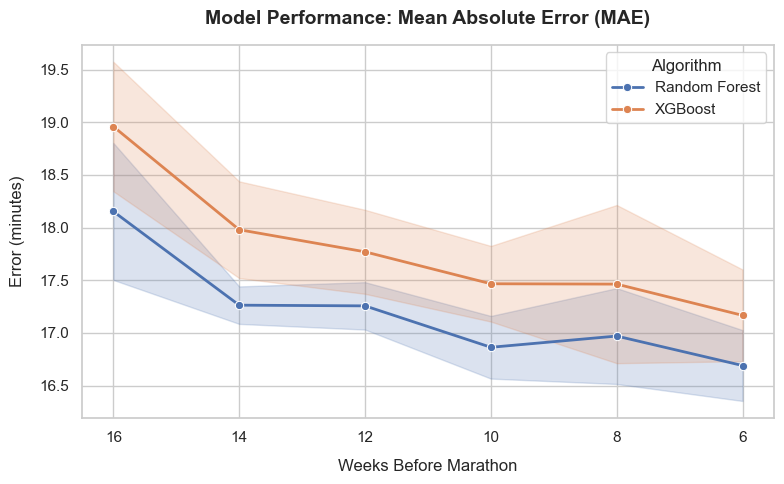

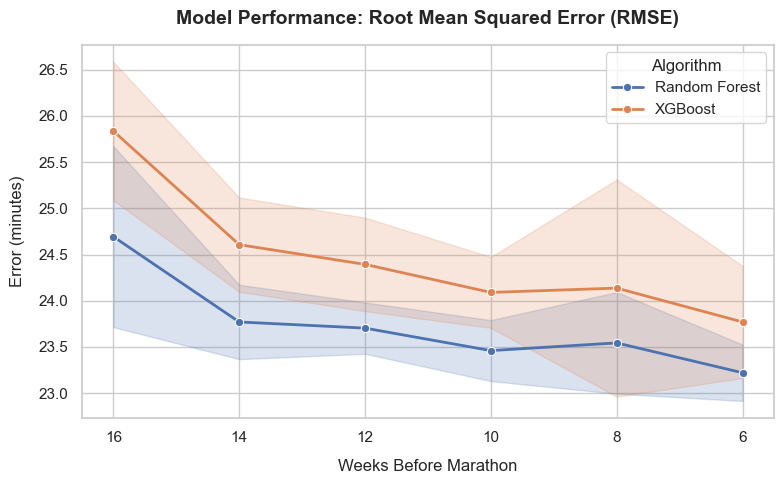

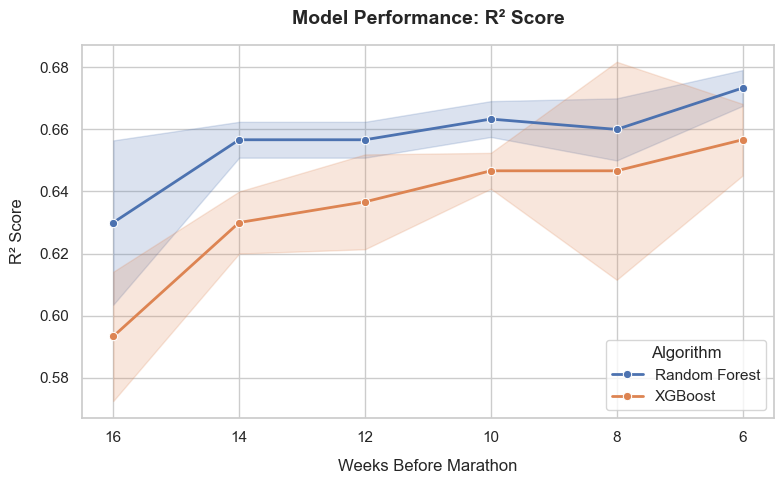

|   Weeks | Model         | MAE (mins)   | RMSE (mins)   | R² Score    |
|--------:|:--------------|:-------------|:--------------|:------------|
|      16 | XGBoost       | 18.96 ± 0.61 | 25.84 ± 0.75  | 0.59 ± 0.02 |
|      16 | Random Forest | 18.15 ± 0.65 | 24.69 ± 0.98  | 0.63 ± 0.03 |
|      14 | XGBoost       | 17.98 ± 0.46 | 24.61 ± 0.51  | 0.63 ± 0.01 |
|      14 | Random Forest | 17.26 ± 0.18 | 23.77 ± 0.40  | 0.66 ± 0.01 |
|      12 | Random Forest | 17.26 ± 0.23 | 23.70 ± 0.28  | 0.66 ± 0.01 |
|      12 | XGBoost       | 17.77 ± 0.40 | 24.39 ± 0.51  | 0.64 ± 0.02 |
|      10 | Random Forest | 16.86 ± 0.30 | 23.46 ± 0.33  | 0.66 ± 0.01 |
|      10 | XGBoost       | 17.47 ± 0.36 | 24.09 ± 0.38  | 0.65 ± 0.01 |
|       8 | Random Forest | 16.97 ± 0.46 | 23.54 ± 0.55  | 0.66 ± 0.01 |
|       8 | XGBoost       | 17.46 ± 0.75 | 24.14 ± 1.18  | 0.65 ± 0.04 |
|       6 | Random Forest | 16.69 ± 0.34 | 23.22 ± 0.31  | 0.67 ± 0.01 |
|       6 | XGBoost       | 17.17 ± 0.44 | 23.77 ± 

In [2]:
# Prepare the Data
data = [
    # 16 Weeks
    {"Weeks": 16, "Model": "Random Forest", "Seed": 42, "MAE": 18.18, "RMSE": 25.03, "R2": 0.62},
    {"Weeks": 16, "Model": "XGBoost",       "Seed": 42, "MAE": 18.61, "RMSE": 25.74, "R2": 0.60},
    {"Weeks": 16, "Model": "Random Forest", "Seed": 52, "MAE": 18.79, "RMSE": 25.46, "R2": 0.61},
    {"Weeks": 16, "Model": "XGBoost",       "Seed": 52, "MAE": 19.67, "RMSE": 26.63, "R2": 0.57},
    {"Weeks": 16, "Model": "Random Forest", "Seed": 62, "MAE": 17.49, "RMSE": 23.59, "R2": 0.66},
    {"Weeks": 16, "Model": "XGBoost",       "Seed": 62, "MAE": 18.60, "RMSE": 25.14, "R2": 0.61},
    
    # 14 Weeks
    {"Weeks": 14, "Model": "Random Forest", "Seed": 42, "MAE": 17.42, "RMSE": 23.86, "R2": 0.66},
    {"Weeks": 14, "Model": "XGBoost",       "Seed": 42, "MAE": 18.26, "RMSE": 24.86, "R2": 0.63},
    {"Weeks": 14, "Model": "Random Forest", "Seed": 52, "MAE": 17.30, "RMSE": 24.12, "R2": 0.65},
    {"Weeks": 14, "Model": "XGBoost",       "Seed": 52, "MAE": 18.23, "RMSE": 24.94, "R2": 0.62},
    {"Weeks": 14, "Model": "Random Forest", "Seed": 62, "MAE": 17.07, "RMSE": 23.33, "R2": 0.66},
    {"Weeks": 14, "Model": "XGBoost",       "Seed": 62, "MAE": 17.45, "RMSE": 24.02, "R2": 0.64},

    # 12 Weeks
    {"Weeks": 12, "Model": "Random Forest", "Seed": 42, "MAE": 17.35, "RMSE": 23.66, "R2": 0.66},
    {"Weeks": 12, "Model": "XGBoost",       "Seed": 42, "MAE": 18.08, "RMSE": 24.95, "R2": 0.62},
    {"Weeks": 12, "Model": "Random Forest", "Seed": 52, "MAE": 17.42, "RMSE": 24.00, "R2": 0.65},
    {"Weeks": 12, "Model": "XGBoost",       "Seed": 52, "MAE": 17.91, "RMSE": 24.27, "R2": 0.64},
    {"Weeks": 12, "Model": "Random Forest", "Seed": 62, "MAE": 17.00, "RMSE": 23.45, "R2": 0.66},
    {"Weeks": 12, "Model": "XGBoost",       "Seed": 62, "MAE": 17.32, "RMSE": 23.96, "R2": 0.65},

    # 10 Weeks
    {"Weeks": 10, "Model": "Random Forest", "Seed": 42, "MAE": 17.04, "RMSE": 23.63, "R2": 0.66},
    {"Weeks": 10, "Model": "XGBoost",       "Seed": 42, "MAE": 17.60, "RMSE": 24.03, "R2": 0.65},
    {"Weeks": 10, "Model": "Random Forest", "Seed": 52, "MAE": 17.03, "RMSE": 23.67, "R2": 0.66},
    {"Weeks": 10, "Model": "XGBoost",       "Seed": 52, "MAE": 17.74, "RMSE": 24.50, "R2": 0.64},
    {"Weeks": 10, "Model": "Random Forest", "Seed": 62, "MAE": 16.52, "RMSE": 23.08, "R2": 0.67},
    {"Weeks": 10, "Model": "XGBoost",       "Seed": 62, "MAE": 17.06, "RMSE": 23.74, "R2": 0.65},

    # 8 Weeks
    {"Weeks": 8, "Model": "Random Forest", "Seed": 42, "MAE": 17.42, "RMSE": 24.09, "R2": 0.65},
    {"Weeks": 8, "Model": "XGBoost",       "Seed": 42, "MAE": 18.19, "RMSE": 25.32, "R2": 0.61},
    {"Weeks": 8, "Model": "Random Forest", "Seed": 52, "MAE": 16.98, "RMSE": 23.55, "R2": 0.66},
    {"Weeks": 8, "Model": "XGBoost",       "Seed": 52, "MAE": 17.51, "RMSE": 24.12, "R2": 0.65},
    {"Weeks": 8, "Model": "Random Forest", "Seed": 62, "MAE": 16.51, "RMSE": 22.99, "R2": 0.67},
    {"Weeks": 8, "Model": "XGBoost",       "Seed": 62, "MAE": 16.69, "RMSE": 22.97, "R2": 0.68},

    # 6 Weeks
    {"Weeks": 6, "Model": "Random Forest", "Seed": 42, "MAE": 17.07, "RMSE": 23.47, "R2": 0.67},
    {"Weeks": 6, "Model": "XGBoost",       "Seed": 42, "MAE": 17.30, "RMSE": 24.15, "R2": 0.65},
    {"Weeks": 6, "Model": "Random Forest", "Seed": 52, "MAE": 16.57, "RMSE": 23.31, "R2": 0.67},
    {"Weeks": 6, "Model": "XGBoost",       "Seed": 52, "MAE": 17.52, "RMSE": 24.09, "R2": 0.65},
    {"Weeks": 6, "Model": "Random Forest", "Seed": 62, "MAE": 16.43, "RMSE": 22.88, "R2": 0.68},
    {"Weeks": 6, "Model": "XGBoost",       "Seed": 62, "MAE": 16.68, "RMSE": 23.07, "R2": 0.67},
]

df = pd.DataFrame(data)

# Configure the Plot Styling
sns.set_theme(style="whitegrid")

# ==========================================
# GRAPH 1: MAE
# ==========================================
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="Weeks", y="MAE", hue="Model", marker="o", linewidth=2, errorbar="sd")
plt.gca().invert_xaxis()
plt.title("Model Performance: Mean Absolute Error (MAE)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Weeks Before Marathon", fontsize=12, labelpad=10)
plt.ylabel("Error (minutes)", fontsize=12, labelpad=10)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: RMSE
# ==========================================
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="Weeks", y="RMSE", hue="Model", marker="o", linewidth=2, errorbar="sd")
plt.gca().invert_xaxis()
plt.title("Model Performance: Root Mean Squared Error (RMSE)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Weeks Before Marathon", fontsize=12, labelpad=10)
plt.ylabel("Error (minutes)", fontsize=12, labelpad=10)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 3: R² Score
# ==========================================
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="Weeks", y="R2", hue="Model", marker="o", linewidth=2, errorbar="sd")
plt.gca().invert_xaxis()
plt.title("Model Performance: R² Score", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Weeks Before Marathon", fontsize=12, labelpad=10)
plt.ylabel("R² Score", fontsize=12, labelpad=10)
plt.legend(title="Algorithm", loc="lower right")
plt.tight_layout()
plt.show()

# ==========================================
# Mean and Standard Deviation of Results
# ==========================================
# Group the data and calculate Mean and Standard Deviation (std)
summary_df = df.groupby(['Weeks', 'Model']).agg({
    'MAE': ['mean', 'std'],
    'RMSE': ['mean', 'std'],
    'R2': ['mean', 'std']
}).reset_index()

# Format the columns into the academic "Mean ± SD" style
for metric in ['MAE', 'RMSE', 'R2']:
    # Grab the calculated mean and std columns
    mean_series = summary_df[metric]['mean']
    std_series = summary_df[metric]['std']
    
    # Combine them into a single string with 2 decimal places
    summary_df[f'{metric}_formatted'] = mean_series.map('{:.2f}'.format) + ' ± ' + std_series.map('{:.2f}'.format)

# Clean up the final table structure
final_table = pd.DataFrame({
    'Weeks': summary_df['Weeks'],
    'Model': summary_df['Model'],
    'MAE (mins)': summary_df['MAE_formatted'],
    'RMSE (mins)': summary_df['RMSE_formatted'],
    'R² Score': summary_df['R2_formatted']
})

# Sort so 16 weeks is at the top
final_table = final_table.sort_values(by='Weeks', ascending=False)

# Print the final result in Markdown format!
print(final_table.to_markdown(index=False))

| Category  | Seed | Model             | MAE (min) | RMSE (min) | R² Score |
|-----------|------|-------------------|-----------|------------|----------|
| Benchmark | 42   | Linear Regression | 27.98     | 36.76      | 0.47     |
| Benchmark | 42   | Random Forest     | 21.84     | 30.15      | 0.64     |
| Benchmark | 42   | XGBoost           | 21.39     | 29.68      | 0.65     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 16    | 42   | Random Forest | 18.18     | 25.03      | 0.62     |
|       |      | XGBoost       | 18.61     | 25.74      | 0.60     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 16    | 52   | Random Forest | 18.79     | 25.46      | 0.61     |
|       |      | XGBoost       | 19.67     | 26.63      | 0.57     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 16    | 62   | Random Forest | 17.49     | 23.59      | 0.66     |
|       |      | XGBoost       | 18.60     | 25.14      | 0.61     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 14    | 42   | Random Forest | 17.42     | 23.86      | 0.66     |
|       |      | XGBoost       | 18.26     | 24.86      | 0.63     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 14    | 52   | Random Forest | 17.3      | 24.12      | 0.65     |
|       |      | XGBoost       | 18.23     | 24.94      | 0.62     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 14    | 62   | Random Forest | 17.07     | 23.33      | 0.66     |
|       |      | XGBoost       | 17.45     | 24.02      | 0.64     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 12    | 42   | Random Forest | 17.35     | 23.66      | 0.66     |
|       |      | XGBoost       | 18.08     | 24.95      | 0.62     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 12    | 52   | Random Forest | 17.42     | 24.00      | 0.65     |
|       |      | XGBoost       | 17.91     | 24.27      | 0.64     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 12    | 62   | Random Forest | 17.00     | 23.45      | 0.66     |
|       |      | XGBoost       | 17.32     | 23.96      | 0.65     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 10    | 42   | Random Forest | 17.04     | 23.63      | 0.66     |
|       |      | XGBoost       | 17.60     | 24.03      | 0.65     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 10    | 52   | Random Forest | 17.03     | 23.67      | 0.66     |
|       |      | XGBoost       | 17.74     | 24.50      | 0.64     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 10    | 62   | Random Forest | 16.52     | 23.08      | 0.67     |
|       |      | XGBoost       | 17.06     | 23.74      | 0.65     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 8     | 42   | Random Forest | 17.42     | 24.09      | 0.65     |
|       |      | XGBoost       | 18.19     | 25.32      | 0.61     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 8     | 52   | Random Forest | 16.98     | 23.55      | 0.66     |
|       |      | XGBoost       | 17.51     | 24.12      | 0.65     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 8     | 62   | Random Forest | 16.51     | 22.99      | 0.67     |
|       |      | XGBoost       | 16.69     | 22.97      | 0.68     |

| Weeks | Seed | Model         | MAE (min) | RMSE (min) | R² Score |
|-------|------|---------------|-----------|------------|----------|
| 6     | 42   | Random Forest | 17.07     | 23.47      | 0.67     |
|       |      | XGBoost       | 17.30     | 24.15      | 0.65     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 6     | 52   | Random Forest | 16.57     | 23.31      | 0.67     |
|       |      | XGBoost       | 17.52     | 24.09      | 0.65     |
| ---   | ---  | ---           | ---       | ---        | ---      |
| 6     | 62   | Random Forest | 16.43     | 22.88      | 0.68     |
|       |      | XGBoost       | 16.68     | 23.07      | 0.67     |